# 🧪 Respostas da Prova Técnica

Este notebook deve conter as suas respostas para a prova técnica da vaga de Analista de Dados Júnior da ATMO ENERGIA.

## 1. Leitura e entendimento dos dados

In [542]:
#Instalando e Importando as bibliotecas necessárias
! pip install pandas
! pip install statsmodels
! pip install matplotlib.pyplot
! pip install seaborn


import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable


ERROR: Could not find a version that satisfies the requirement matplotlib.pyplot (from versions: none)

[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: No matching distribution found for matplotlib.pyplot


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [543]:
# Carregue aqui os arquivos `vazoes.csv` e `posto.csv` com pandas
vazoes = pd.read_csv("vazoes.csv", sep=";")
posto = pd.read_csv("posto.csv", sep=";")

In [544]:
# Exiba as primeiras linhas dos datasets
print(f"Primeiras 5 linhas do arquivo vazões: \n {vazoes.head()} \n Primeiras 5 linhas do arquivo posto: \n {posto.head()}")

Primeiras 5 linhas do arquivo vazões: 
    posto        data   vazao
0      1  2025-02-03  280,95
1      1  2025-02-04  273,48
2      1  2025-02-05  263,71
3      1  2025-02-06  240,05
4      1  2025-02-07  208,74 
 Primeiras 5 linhas do arquivo posto: 
    posto produtibilidade submercado   bacia
0      1          0,2076         se  grande
1      2          0,2437         se  grande
2      6           0,813         se  grande
3      7          0,3471         se  grande
4      8          0,5437         se  grande


## COMENTÁRIOS

**Descrição dos dados:** 
No arquivo "vazões" podemos visualizar 3 colunas, contendo a vazão diária de cada posto, com datas de 03 de fevereiro a 24 de março de 2025. Os dados são organizados por "posto", contendo a vazão diária em cada posto. Alguns postos possuem dados faltantes de vazão e outros possuem a série completa.

No arquivo "posto" podemos visualizar 4 colunas, onde vemos o próprio posto, a produtibilidade (índice referente ao potencial de geração de energia hidrelétrica desse posto), o submercado (região do Brasil) e o nome de bacia, nos quais cada posto pertence.

Entre os arquivos "vazão" e "posto" existe uma chave comum entre eles, que é o próprio número do posto, por meio dessa chave, podemos relacionar (como um JOIN no SQL) as vazões diárias com informações como produtibilidade, submercado e bacia.

O arquivo de cadastro/dimensão é o arquivo "Posto", pois apresenta dados de referência, em que foi necessária uma série de estudos para alcançar aquele determinado valor, por exemplo, o valor da produtibilidade de cada posto. Além disso, as informações de submercado e bacia de cada posto não serão alteradas (são "imutáveis"), a não ser que a classificação desses termos também mude.

Portanto, o arquivo que mostra fatos/eventos é o arquivo "Vazões", visto que ele representa apenas medições diárias da vazão de um posto em um período de tempo (nesse caso, de quase 2 meses), que está sujeita a grandes variações, dependendo dos fatores e situação que a envolva (por exemplo: quantidade de chuva que ocorreu em um dia, que altera a vazão do rio).

## 2. Limpeza e pré-processamento

In [545]:
# Verifique valores nulos e tipos de dados

#A função isnull() atribui True (1 - nulo) ou False (0 - não nulo), somando todos os "True", temos o total de dados nulos
nulos_vazoes = vazoes.isnull().sum() 
nulos_posto = posto.isnull().sum()

print(f"Antes do tratamento:\n"
      f"Existem {nulos_vazoes[0]} itens nulos na coluna posto, {nulos_vazoes[1]} na coluna data e {nulos_vazoes[2]} itens nulos na coluna vazão.\n"
      f"Existem {nulos_posto[0]} itens nulos na coluna posto, {nulos_posto[1]}, na coluna produtibilidade, {nulos_posto[2]} na coluna submercado e {nulos_posto[3]} na coluna bacia.")

#Precisamos tratar somente os dados do arquivo vazões, porque não há dados faltantes em "posto"

vazoes.vazao.describe() #Descrição geral dos dados
#Além de dados faltantes, percebemos que há valores negativos, que não fazem sentido para uma métrica de vazão

#Vamos ver esses dados nulos
dados_nulos = vazoes[vazoes.isnull().any(axis=1)]
print(dados_nulos)

#Como a vazão é uma medida diária e dependente de diversos fatores, como a chuva e a evaporação, e não temos nenhuma informação sobre esses fatores
#vamos excluir os dados faltantes do nosso arquivo, porque não temos como estimar essa medida com as informações disponíveis

vazoes.dropna(inplace=True)
#vazoes

#Só para verificar
nulos_vazoes = vazoes.isna().sum()

print(f"Depois do tratamento:\n"
      f"Existem {nulos_vazoes[0]} itens nulos na coluna data e {nulos_vazoes[1]} itens nulos na coluna vazão.")

#Pronto, sem dados faltantes!


Antes do tratamento:
Existem 0 itens nulos na coluna posto, 0 na coluna data e 39 itens nulos na coluna vazão.
Existem 0 itens nulos na coluna posto, 0, na coluna produtibilidade, 0 na coluna submercado e 0 na coluna bacia.
      posto        data vazao
1913     52  2025-02-16   NaN
1914     52  2025-02-17   NaN
1915     52  2025-02-18   NaN
1916     52  2025-02-19   NaN
1917     52  2025-02-20   NaN
1918     52  2025-02-21   NaN
1919     52  2025-02-22   NaN
1920     52  2025-02-23   NaN
1921     52  2025-02-24   NaN
1922     52  2025-02-25   NaN
2109     57  2025-02-12   NaN
2110     57  2025-02-13   NaN
2111     57  2025-02-14   NaN
2112     57  2025-02-15   NaN
2113     57  2025-02-16   NaN
2114     57  2025-02-17   NaN
2115     57  2025-02-18   NaN
2116     57  2025-02-19   NaN
2117     57  2025-02-20   NaN
2118     57  2025-02-21   NaN
2119     57  2025-02-22   NaN
2120     57  2025-02-23   NaN
2121     57  2025-02-24   NaN
2122     57  2025-02-25   NaN
2123     57  2025-02-26   

C:\Users\gabil\AppData\Local\Temp\ipykernel_4472\1253125511.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  f"Existem {nulos_vazoes[0]} itens nulos na coluna posto, {nulos_vazoes[1]} na coluna data e {nulos_vazoes[2]} itens nulos na coluna vazão.\n"
C:\Users\gabil\AppData\Local\Temp\ipykernel_4472\1253125511.py:9: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  f"Existem {nulos_posto[0]} itens nulos na coluna posto, {nulos_posto[1]}, na coluna produtibilidade, {nulos_posto[2]} na coluna submercado e {nulos_posto[3]} na coluna bacia.")
C:\Users\gabil\AppData\Local\Temp\ipykernel_4472\1253125511.py:30: FutureWarning:

In [546]:
#Agora vamos tratar os dados negativos de vazão, que claramente estão errados
#Para isso, precisamos converter os tipos de dados

#Verificando o tipo dos dados e fazendo transformações

vazoes.dtypes #Colunas do tipo object
posto.dtypes #Colunas do tipo object

#Transformações nos dados de Vazão

vazoes.vazao = vazoes.vazao.str.replace(",", ".") #padronizando o ponto e tirando a vírgula

vazoes = vazoes.astype({
    'data': 'datetime64[s]',
    'vazao': 'float'
})

#Transformações nos dados do Posto

posto.produtibilidade = posto.produtibilidade.str.replace(",", ".") #padronizando o ponto e tirando a vírgula

posto = posto.astype({
    'produtibilidade': 'float',
    'submercado': 'string',
    'bacia': 'string'
})

#Só para confirmar nossas transformações

print(f"{vazoes.dtypes}, \n {posto.dtypes}")

posto            int64
data     datetime64[s]
vazao          float64
dtype: object, 
 posto                       int64
produtibilidade           float64
submercado         string[python]
bacia              string[python]
dtype: object


In [547]:
#Tratando os valores negativos da vazão, vamos excluí-los da nossa base, por serem erros

dados_negativos = vazoes[vazoes.vazao < 0]
print(dados_negativos)

vazoes = vazoes[vazoes.vazao >= 0] #assim excluímos esses dados negativos
print(vazoes)

#Conferindo se deu certo
#vazoes.vazao.describe()

#Também vamos excluir os dados dos postos com produtibilidade = 0, pois eles não são usados para geração de energia hidroelétrica
posto = posto[posto.produtibilidade != 0]
print(posto)

#Conferindo se deu certo
posto.produtibilidade.describe()


      posto       data      vazao
2325     63 2025-02-28     -88.00
2326     63 2025-03-01    -250.48
2327     63 2025-03-02 -999999.65
2773     77 2025-02-26    -980.88
3299     94 2025-03-24    -300.35
          posto       data       vazao
0             1 2025-02-03  280.950000
1             1 2025-02-04  273.480000
2             1 2025-02-05  263.710000
3             1 2025-02-06  240.050000
4             1 2025-02-07  208.740000
...         ...        ...         ...
12195  65310001 2025-03-20  234.800003
12196  65310001 2025-03-21  231.899994
12197  65310001 2025-03-22  224.500000
12198  65310001 2025-03-23  212.300003
12199  65310001 2025-03-24  200.500000

[12156 rows x 3 columns]
     posto  produtibilidade submercado           bacia
0        1           0.2076         se          grande
1        2           0.2437         se          grande
2        6           0.8130         se          grande
3        7           0.3471         se          grande
4        8           0.5437

count    151.000000
mean       0.664957
std        0.797810
min        0.096200
25%        0.240150
50%        0.436000
75%        0.815750
max        6.354200
Name: produtibilidade, dtype: float64

## COMENTÁRIOS

**Alterações feitas:** 
- O primeiro passo foi avaliar se havia dados nulos nos dataframes e foi constatado que só havia dados faltantes na coluna "vazão" da tabela "vazões". Como a vazão é uma medida com flutuações diárias e não pode ser prevista  sem considerar outros fatores (como chuva, evaporação), a melhor opção é excluir esses dados, para não comprometer a qualidade dos nossos dados. Como eram somente 39 dados faltantes, de mais de 12 mil observações, não teria grande problema ou perda em fazer essa exclusão.

- Depois disso, foi feita a mudança dos tipos dos dados, que antes estavam todos em "object" e precisamos de dados numéricos para realizar as operações matemáticas. Também foi alterada a "vírgula" dos dados numéricos para "ponto", que é o padrão americano.

- O terceiro passo foi excluir os dados inconsistentes da coluna "vazão", pois havia dados negativos, que não fazem sentido para quantificar essa medida, que é expressa em m³/s (volume por tempo).

- O quarto passo foi excluir os dados de "produtibilidade" iguais a 0.0. Foi adotada essa medida porque a produtibilidade está associada com o potencial de geração de energia elétrica, se ela é 0.0, pode ser: ou que esse dado tenha sido lançado como default e ainda não há o dado real, ou que o posto não é usado para geração de energia elétrica. De qualquer maneira, faz sentido para a nossa análise a exclusão desses dados.


## 3. Análise Estatística Descritiva

In [548]:
# Calcule estatísticas como média, mediana, desvio-padrão, etc.
descricao = vazoes.vazao.describe() 

#A função .describe() já fornece todas as informações descritivas necessárias para ter uma visão geral dos dados

print(f"VAZÃO:\n"
      f"Total de dados: {descricao['count']}\n"
      f"Vazão média: {descricao['mean']}\n"
      f"Desvio-padrão: {descricao['std']}\n"
      f"Vazão mínima: {descricao['min']}\n"
      f"Vazão máxima: {descricao['max']}\n"
      f"Quantil de 25%: {descricao['25%']}\n"
      f"Mediana: {descricao['50%']}\n"
      f"Quantil de 75%: {descricao['75%']}\n")

# Calcule estatísticas como média, mediana, desvio-padrão, etc.
descricao = posto.produtibilidade.describe() 

#A função .describe() já fornece todas as informações descritivas necessárias para ter uma visão geral dos dados

print(f"PRODUTIBILIDADE:\n"
      f"Total de dados: {descricao['count']}\n"
      f"Produtibilidade média: {descricao['mean']}\n"
      f"Desvio-padrão: {descricao['std']}\n"
      f"Produtibilidade mínima: {descricao['min']}\n"
      f"Produtibilidade máxima: {descricao['max']}\n"
      f"Quantil de 25%: {descricao['25%']}\n"
      f"Mediana: {descricao['50%']}\n"
      f"Quantil de 75%: {descricao['75%']}")

VAZÃO:
Total de dados: 12156.0
Vazão média: 1279.462468989634
Desvio-padrão: 3979.397073938623
Vazão mínima: 0.0
Vazão máxima: 40820.45
Quantil de 25%: 29.445
Mediana: 190.0
Quantil de 75%: 746.1525

PRODUTIBILIDADE:
Total de dados: 151.0
Produtibilidade média: 0.6649569536423842
Desvio-padrão: 0.7978102588552355
Produtibilidade mínima: 0.0962
Produtibilidade máxima: 6.3542
Quantil de 25%: 0.24014999999999997
Mediana: 0.436
Quantil de 75%: 0.81575


In [549]:
# Explore possíveis correlações
# GERAL - TODOS OS POSTOS POR SUBMERCADO

total_postos = len(posto)
submercado_se = posto.query("submercado == 'se'").shape[0] 
submercado_s = posto.query("submercado == 's'").shape[0]
submercado_ne = posto.query("submercado == 'ne'").shape[0]
submercado_n = posto.query("submercado == 'n'").shape[0]

print(f"Existem {total_postos} postos por submercado!\n"
      f"Dentre eles:\n"
      f"{round((submercado_ne/total_postos)*100,2)}% está no submercado NE\n"
      f"{round((submercado_n/total_postos)*100,2)}% está no submercado N\n"
      f"{round((submercado_se/total_postos)*100,2)}% está no submercado SE\n"
      f"{round((submercado_s/total_postos)*100,2)}% está no submercado S\n"
)

Existem 151 postos por submercado!
Dentre eles:
4.64% está no submercado NE
6.62% está no submercado N
69.54% está no submercado SE
19.21% está no submercado S



In [550]:
# POSTOS ACIMA DO PERCENTIL 75%
percentil_75 = 0.81575
percentil_25 = 0.24015

valores_percentil_75 = posto[posto.produtibilidade >= 0.81575].sort_values('produtibilidade', ascending=False)
valores_percentil_25 = posto[posto.produtibilidade <= 0.24015].sort_values('produtibilidade', ascending=False)

total_postos = len(valores_percentil_75)
submercado_se = valores_percentil_75.query("submercado == 'se'").shape[0] #filtrando os dados e mostrando a sua contagem
submercado_s = valores_percentil_75.query("submercado == 's'").shape[0]
submercado_ne = valores_percentil_75.query("submercado == 'ne'").shape[0]
submercado_n = valores_percentil_75.query("submercado == 'n'").shape[0]

print(f"Existem {total_postos} postos com produtibilidade >= {percentil_75}!\n"
      f"Dentre elas:\n"
      f"{round((submercado_ne/total_postos)*100,2)}% está no submercado NE\n"
      f"{round((submercado_n/total_postos)*100,2)}% está no submercado N\n"
      f"{round((submercado_se/total_postos)*100,2)}% está no submercado SE\n"
      f"{round((submercado_s/total_postos)*100,2)}% está no submercado S\n"
)

Existem 38 postos com produtibilidade >= 0.81575!
Dentre elas:
7.89% está no submercado NE
2.63% está no submercado N
55.26% está no submercado SE
34.21% está no submercado S



In [551]:
# POSTOS ABAIXO DO PERCENTIL 25%

total_postos = len(valores_percentil_25)
submercado_se = valores_percentil_25.query("submercado == 'se'").shape[0] #filtrando os dados e mostrando a sua contagem
submercado_s = valores_percentil_25.query("submercado == 's'").shape[0]
submercado_ne = valores_percentil_25.query("submercado == 'ne'").shape[0]
submercado_n = valores_percentil_25.query("submercado == 'n'").shape[0]

print(f"Existem {total_postos} postos com produtibilidade <= {percentil_25}!\n"
      f"Dentre elas:\n"
      f"{round((submercado_ne/total_postos)*100,2)}% está no submercado NE\n"
      f"{round((submercado_n/total_postos)*100,2)}% está no submercado N\n"
      f"{round((submercado_se/total_postos)*100,2)}% está no submercado SE\n"
      f"{round((submercado_s/total_postos)*100,2)}% está no submercado S\n"
)

Existem 38 postos com produtibilidade <= 0.24015!
Dentre elas:
0.0% está no submercado NE
21.05% está no submercado N
73.68% está no submercado SE
5.26% está no submercado S



In [552]:
#Explorando as 10 maiores Produtibilidades da série
posto.sort_values('produtibilidade', ascending=False).head(10)

#7 das 10 maiores está no submercado SE e 3 no submercado S, sendo a maior de todas na bacia do Capivari (S)

,posto,produtibilidade,submercado,bacia
80,115,6.3542,s,capivari
217,318,5.6808,se,alto-tiete
209,303,2.7014,se,paraiba-do-sul
94,131,2.6871,se,paraiba-do-sul
64,93,2.2252,s,uruguai
188,281,2.2106,se,paraguai
137,213,2.1132,se,sta-maria-vitoria
70,101,1.7641,s,itajai-acu
124,196,1.6903,se,itabapoana
106,158,1.6404,se,sao-francisco


In [553]:
#Explorando as 10 menores Produtibilidades da série
posto.sort_values('produtibilidade', ascending=False).tail(10)

#6 das 10 maiores está no submercado SE, 3 no submercado N e 1 no submercado S, sendo a menor de todas na bacia do Paranapanema (SE)

,posto,produtibilidade,submercado,bacia
6,10,0.1523,se,grande
203,297,0.1499,n,araguari
38,52,0.1489,se,paranapanema
36,50,0.1483,se,paranapanema
58,81,0.1458,s,iguacu
131,204,0.1406,n,araguari
37,51,0.1288,se,paranapanema
39,53,0.1275,se,paranapanema
208,302,0.1140,n,xingu
161,249,0.0962,se,paranapanema


- Nessa parte das correlações, foram feitas análises entre os postos e os submercados, mostrando quantos postos existem por submercado, em geral, e depois considerando os postos com as maiores (> percentil 75%) e menores (< percentil de 25%) produtibilidades.

- Percebemos que a região com maior quantidade de postos é a Sudeste (69.5%). A região Sul, aparece em 2º lugar, com 19.2% do total de postos. Ambas as regiões também apresentam a maior quantidade de postos com produtibilidade acima do percentil de 75%, sendo 55.3% e 34.2%, respectivamente. Ou seja, de todos os postos com alta produtibilidade, cerca de 90% está nas regiões SE e S.

- Depois disso, foram classificados os postos de acordo com a produtibilidade, sendo pontuados o top 10 maiores e os 10 últimos em termos de produtibilidade (lembrando que produtibilidade == 0 foram descartados).

- Quando consideramos somente o top 10, 70% das maiores produtibilidades estão na região SE e 30% na região S. Já quando avaliamos os 10 menores, a região que mais aparece é a região SE, com 60% dos postos. Como essa região apresenta quase 70% do total de postos, é aceitável e compreensivo esse resultado.

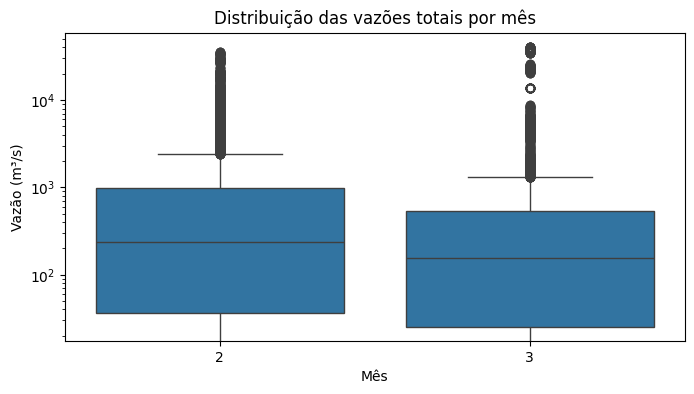

In [554]:
# Crie pelo menos dois gráficos que ajudem a entender o comportamento das vazões

vazoes['mes'] = vazoes['data'].dt.month

figure, ax = plt.subplots(figsize=(8,4))

sns.boxplot(data=vazoes, x='mes', y='vazao')
plt.title('Distribuição das vazões totais por mês')
plt.yscale('log')
plt.xlabel('Mês')
plt.ylabel('Vazão (m³/s)')
plt.show()

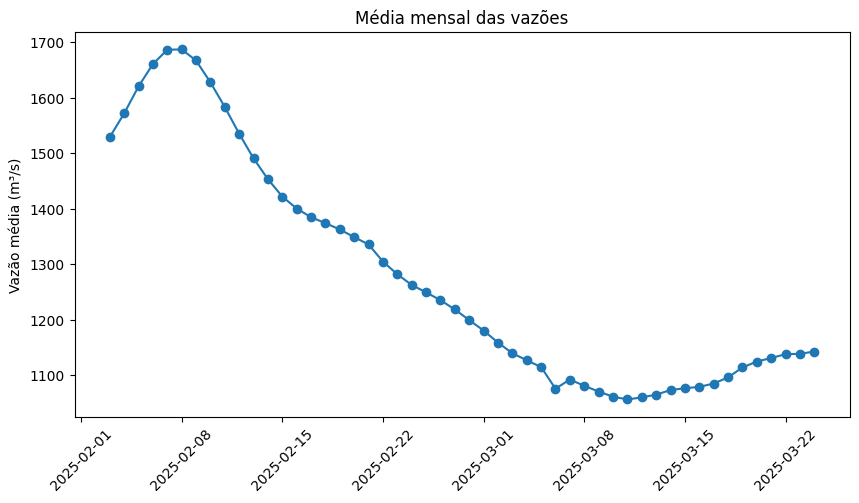

In [555]:
#VAZÃO POR DIA

media_dia_vazao = vazoes.groupby('data')['vazao'].mean().reset_index()

plt.figure(figsize=(10, 5))
plt.plot(media_dia_vazao.data, media_dia_vazao.vazao, marker='o')
plt.xticks(rotation=45)
plt.title('Média mensal das vazões')
plt.ylabel('Vazão média (m³/s)')
plt.show()

**Comentário:** Interprete os resultados obtidos.

- Gáfico 1 (boxplot): a vazão total no mês de fevereiro possui maior mediana do que o mês de março, mostrando que os valores da vazão dos meses de fevereiro são mais altos. A variabilidade (distância interquantil) é bem parecida entre os dois meses, indicando também uma distribuição semelhante, porém, em fevereiro há maior quantidade de outliers (pontos extremos). 
    Provavelmente esses valores possuem uma correlação grande com a precipitação, e sendo fevereiro um mês mais chuvoso (em grande parte do Brasil, de maneira geral), então essa análise e esses valores são coerentes. E os outliers provavelmente estão associados com episódios de chuva intensa, que corroboram com a análise.

- Gráfico 2 (série temporal): com essa série, fica ainda mais clara a explicação acima, que de a vazão está associada com as chuvas. O pico de vazão ocorre no começo de fevereiro, com valores em torno de 1700 m³/s, seguido de uma grande redução e queda, chegando em torno de 1100 m³/s no começo de março (que depois volta a subir um pouco, ~1150 m³/s). Ou seja, vemos um padrão bem alinhado ao comportamento típico da estação chuvosa no Brasil (de forma geral), onde as chuvas mais volumosas ocorrem até fevereiro, seguida por uma redução gradual até se iniciar a época seca.

## 4. Análise Exploratória e Estimativa de Energia

In [556]:
# Realize agrupamentos temporais e por atributos como submercado ou bacia
# Pense em agrupamentos temporais (por exemplo: mês, ano, estação do ano)
#     . Pense em agrupamentos por atributos do posto, como:
#         . Submercado
#         . Bacia hidrográfica
#         . Tipo do posto (se existir)


#Agrupamento de VAZÃO por dia e por mês
media_dia_vazao = vazoes.groupby('data')['vazao'].mean().reset_index()
media_mes_vazao = vazoes.groupby(pd.Grouper(key='data', freq='M'))['vazao'].mean().reset_index()

#Agrupamento de POSTO por submercado e bacia
group_submercado_posto = posto.groupby('submercado')['posto'].count().reset_index()
group_bacia_posto = posto.groupby('bacia')['posto'].count().reset_index()

#Agrupamento de VAZÃO por submercado e bacia
merge = pd.merge(vazoes, posto, on=['posto'], how='left')
group_submercado_vazao = merge.groupby('submercado')['vazao'].mean().reset_index()
group_bacia_vazao = merge.groupby('bacia')['vazao'].mean().reset_index()

C:\Users\gabil\AppData\Local\Temp\ipykernel_4472\3519659974.py:11: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  media_mes_vazao = vazoes.groupby(pd.Grouper(key='data', freq='M'))['vazao'].mean().reset_index()


In [557]:
# Estime a energia (MW) com base na vazão e na produtibilidade dos postos
merge['energia_calculada'] = merge.vazao * merge.produtibilidade
merge.dropna(inplace=True)

energia_individual = merge
energia_total_posto = merge.groupby('posto')['energia_calculada'].sum().reset_index()
energia_total_bacia = merge.groupby('bacia')['energia_calculada'].sum().reset_index()
energia_total_submercado = merge.groupby('submercado')['energia_calculada'].sum().reset_index()

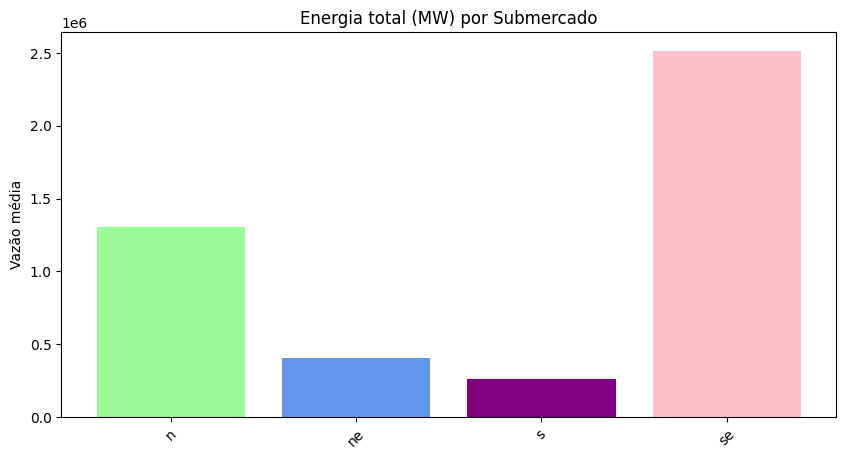

In [558]:
# Gere dataframes e gráficos para análise

plt.figure(figsize=(10, 5))
plt.bar(x=energia_total_submercado.submercado, height=energia_total_submercado.energia_calculada, color=['palegreen', 'cornflowerblue', 'purple', 'pink'])
plt.xticks(rotation=45)
plt.title('Energia total (MW) por Submercado')
plt.ylabel('Vazão média')
plt.show()


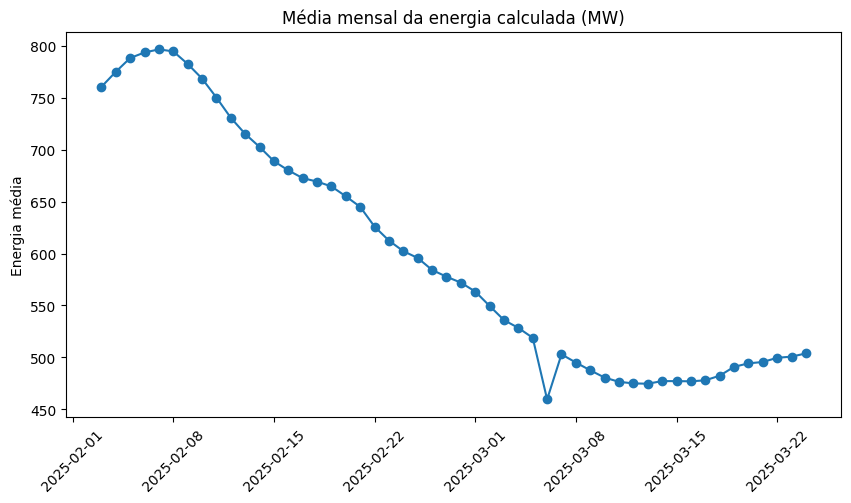

In [559]:
media_dia_energia = energia_individual.groupby('data')['energia_calculada'].mean().reset_index()

plt.figure(figsize=(10, 5))
plt.plot(media_dia_energia.data, media_dia_energia.energia_calculada, marker='o')
plt.xticks(rotation=45)
plt.title('Média mensal da energia calculada (MW)')
plt.ylabel('Energia média')
plt.show()

## **COMENTÁRIOS:**

O interessante de se fazer esses agrupamentos é que podemos ter várias ferramentas para fazer comparações, por exemplo, comparação entre os meses (qual tem maior energia calculada?, qual tem maior vazão?) ou por submercados, onde podemos ver qual região possui maior importância e potencial para geração de energia hidrelétrica e ainda, dentro dessas regiões, quais bacias possuem maior potencial e assim por diante.

Podemos extrair muitas informações relevantes a partir desses dados, por exemplo: a quantidade de energia calculada no submercado SE é ~2.5e6 WM, que representa o maior potencial de todas as regiões do Brasil (mesmo somando as outras 3, a região SE continua tendo maior potencial). Apesar da região Norte não aparecer no topo das produtibilidades, seu potencial ainda é enorme, graças a gigantesca vazão dos rios.
E apresentar da região Sul apresentar altas produtibilidades, seus postos possuem vazões muito baixas e por isso, ficou em último lugar na lista dos potenciais de geração de energia hidrelétrica.

## 5. Modelo de Regressão

In [562]:
# Escolha duas variáveis e aplique uma regressão linear simples
# usando statsmodels

X = merge.vazao #variável independente -- vazão
y =  merge.energia_calculada #variável dependente -- energia

const_X = sm.add_constant(X) #intercepto da regressão

model = sm.OLS(y, const_X).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:      energia_calculada   R-squared:                       0.551
Model:                            OLS   Adj. R-squared:                  0.551
Method:                 Least Squares   F-statistic:                     9222.
Date:                Thu, 10 Apr 2025   Prob (F-statistic):               0.00
Time:                        23:25:34   Log-Likelihood:                -63747.
No. Observations:                7506   AIC:                         1.275e+05
Df Residuals:                    7504   BIC:                         1.275e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        162.6774     14.366     11.324      0.000     134.515     190.839
vazao          0.2873      0.003     96.032      0.000       0.281       0.293
==============================================================================
Omnibus:                     6632.648   Durbin-Watson:                   0.035
Prob(Omnibus):                  0.000   Jarque-Bera (JB):           386420.827
Skew:                           3.996   Prob(JB):                         0.00
Kurtosis:                      37.230   Cond. No.                     5.06e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 5.06e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

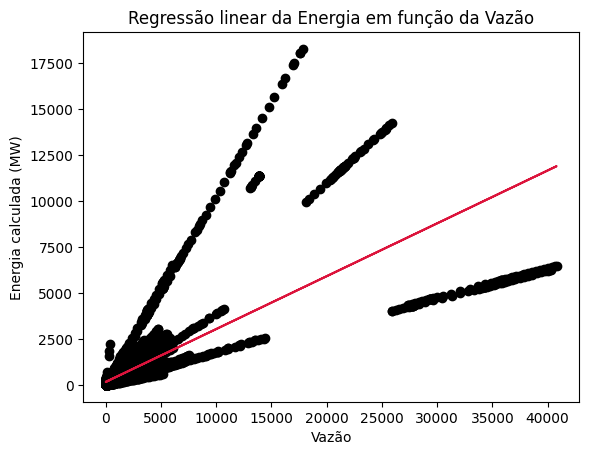

In [563]:
# Avalie os resultados com métricas e gráficos
plt.scatter(X, y, label='Dados reais', color='black')
plt.plot(X, model.predict(const_X), label='Regressão linear', color='crimson')
plt.title('Regressão linear da Energia em função da Vazão')
plt.ylabel('Energia calculada (MW)')
plt.xlabel('Vazão')
plt.show()

## **Comentário:** 

De forma geral, o modelo é bom, o R² = 0.55 é um valor considerado adequado, quando tratamos de dados naturais, com grande variabilidade, ainda considerando nosso escasso conjunto de dados, é um valor adequado para essa análise.

Além disso, o P-value é 0.0, o que representa uma significância estatística super alta entre as variáveis vazão e energia, o que mostra como a vazão é relevante para a energia (o que já era esperado).

Porém, os coeficientes de assimetria (Skew e Kurtosis) estão bem altos e bem positivos, o que indica uma cauda muito pesada a direita, com muitos dados concentrados em valores muito altos de vazão, o que indica que os resíduos não se comportam como uma distribuição normal, que é uma premissa para uma regressão linear.

Com isso, podemos concluir que nosso modelo não é tão ruim assim, considerando nosso conjunto de dados, porém é necessário incluir mais variáveis e dados (maior amostragem) e modelar de forma correta os resíduos, para que possamos ter um modelo mais robusto e com maior acertividade.

## ✅ Conclusão

Faça aqui qualquer consideração final que julgar relevante sobre sua análise ou o processo.

Lembrei das minhas aulas de Hidrometeorologia, foi bem bacana!
Obrigada pela oportunidade!
Espero nos vermos em breve!

Gabriela Flores